In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
import os

os.chdir(Path.cwd().parent)
print("new cwd:", Path.cwd())

new cwd: /home/oliver-hertach/Documents/Master/CO4/ClimbingVault


## Manual Segmentation
Using this dataset: 

https://www.kaggle.com/datasets/tomasslama/indoor-climbing-gym-hold-segmentation/data?select=sm

10 pictures were chosen for the project. To not overcomplicate things, mostly pictures where only one wall at the time is visible, with clearly visible and not too many holds were chosen. The pictures were from the "sm" folder from the dataset, and the original numbering was kept (e.g. 008.jpg). The pictures were manually segmented using Fiji. For each climbing hold color, a binary mask was created and stored as .png, with white pixels representing the holds and black pixels the background.  

Masks were manually created with reasonable visual precision, but not at single-pixel accuracy, as the focus of the project is comparative segmentation evaluation rather than precise annotation benchmarking.

In [2]:
def load_sample(img_id):
    img = cv.imread(f"data/images/{img_id}.jpg")

    mask_dir = f"data/masks/{img_id}"
    
    masks = {}
    
    for file in os.listdir(mask_dir):
        if file.endswith(".png"):
            color = file.replace(".png", "")
            masks[color] = cv.imread(os.path.join(mask_dir, file), 0)

    return img, masks

In [ ]:
colors = {
    "red": [255, 0, 0],
    "blue": [0, 0, 255],
    "green": [0, 255, 0],
    "yellow": [255, 255, 0],
    "orange": [255, 165, 0],
    "purple": [128, 0, 128],
    "pink" : [255, 105, 180],
    "black": [0, 0, 0],
    "downclimb": [128, 128, 128],
}

def visualize(img, masks):
    masks_bin = {k: (v > 0).astype(np.uint8) for k, v in masks.items()}

    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    overlay = img_rgb.copy()

    for name, mask in masks_bin.items():
        overlay[mask == 1] = colors[name]

    # side-by-side visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # original image
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # overlay image
    axes[1].imshow(overlay)
    axes[1].set_title("Manual Segmentation Overlay")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    all_holds = np.zeros_like(next(iter(masks_bin.values())))

    for m in masks_bin.values():
        all_holds = np.logical_or(all_holds, m)

    all_holds = all_holds.astype(np.uint8)

    return all_holds

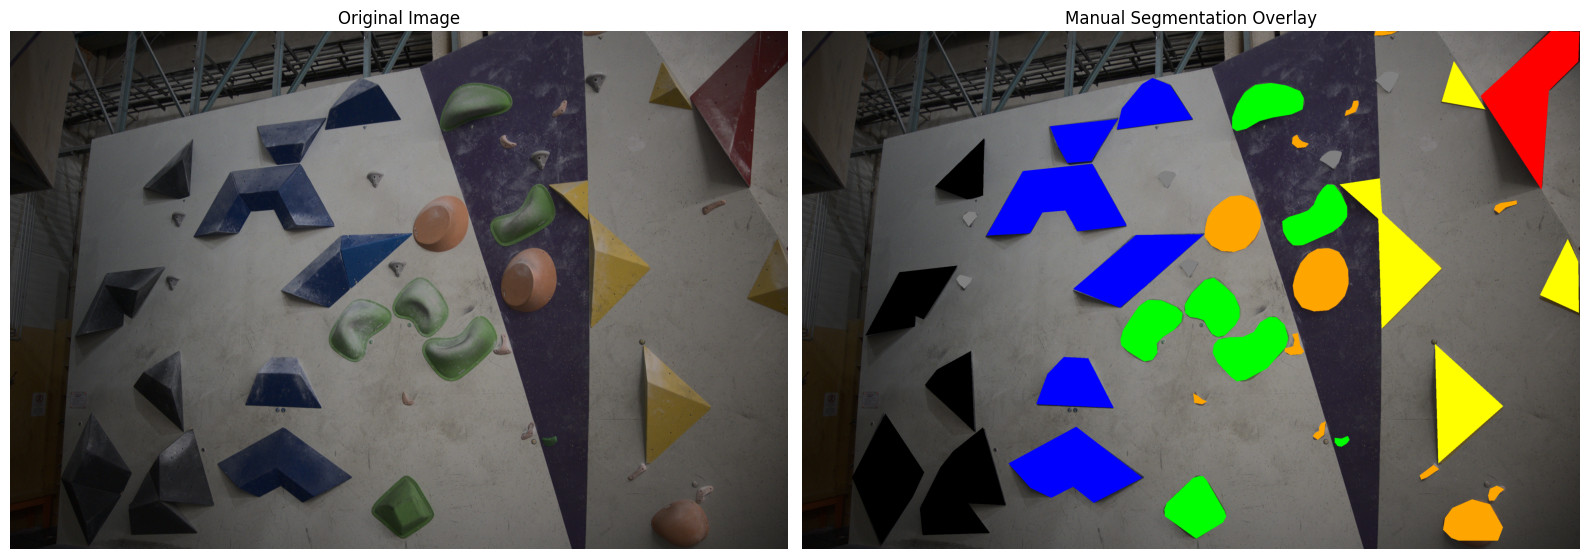

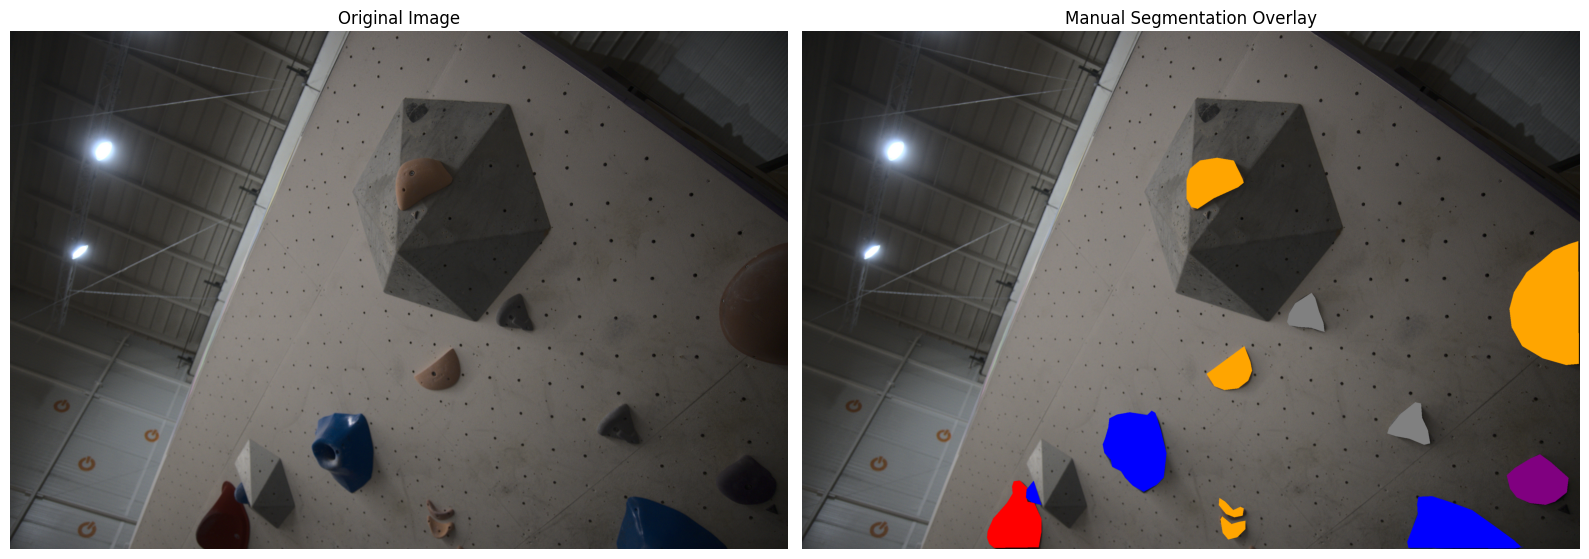

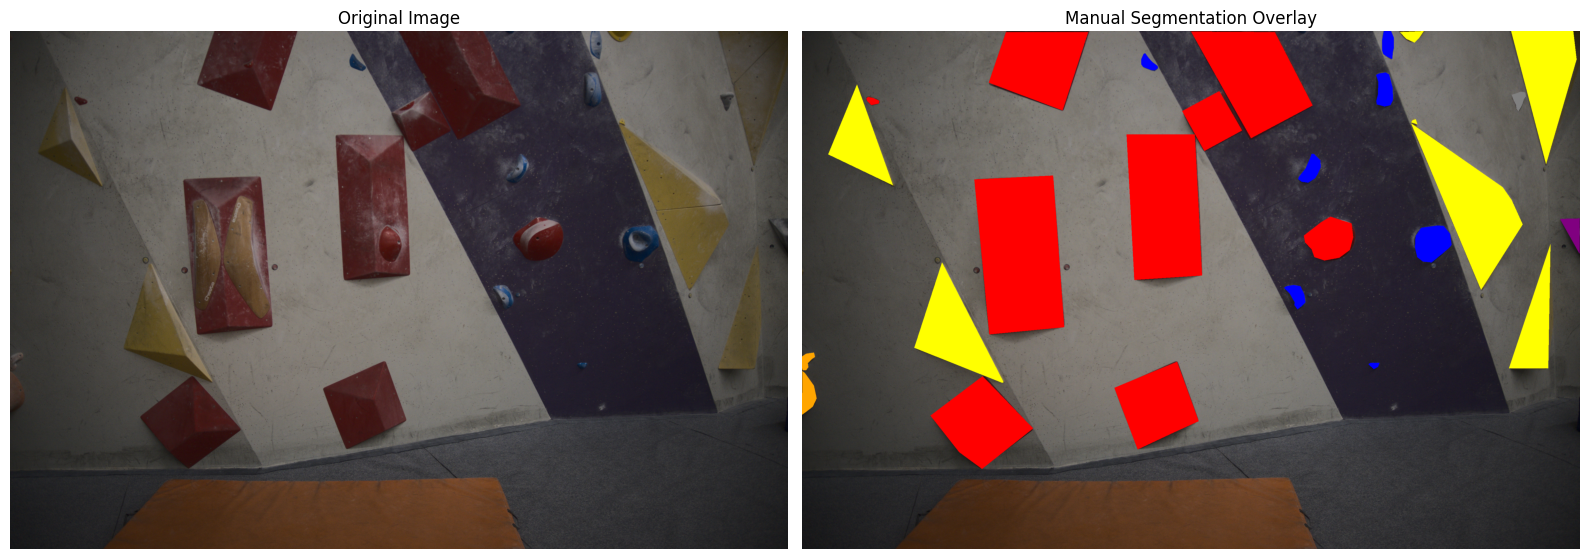

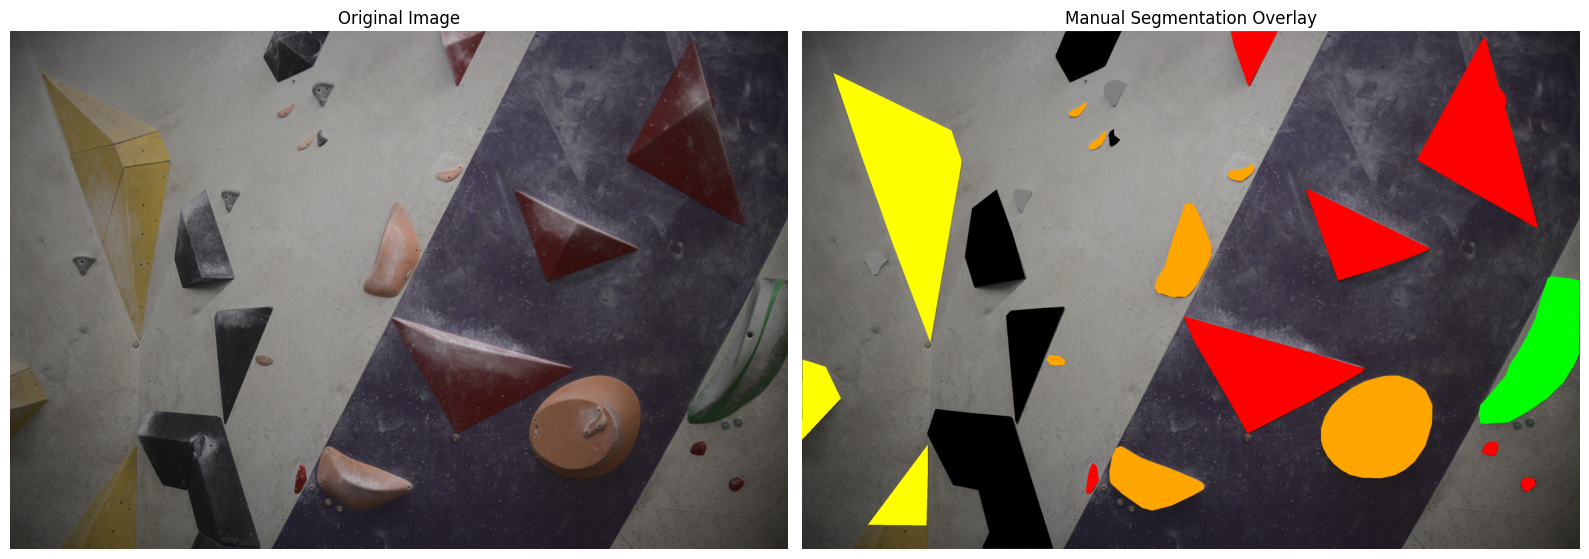

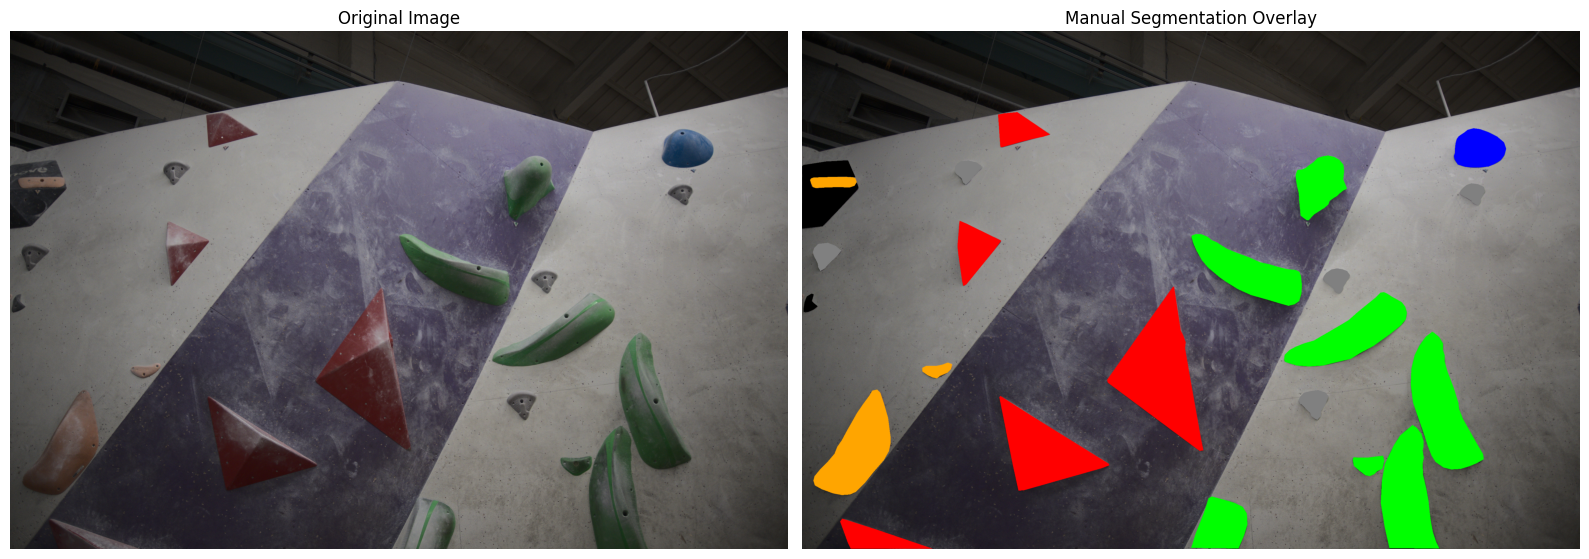

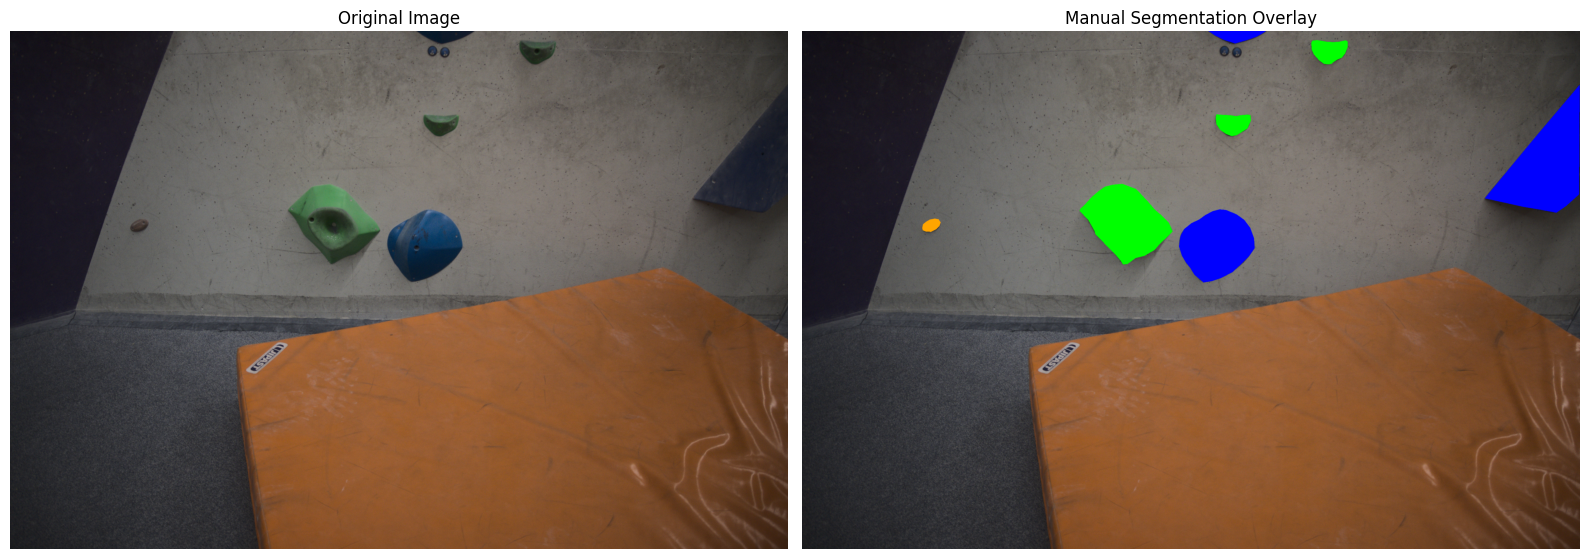

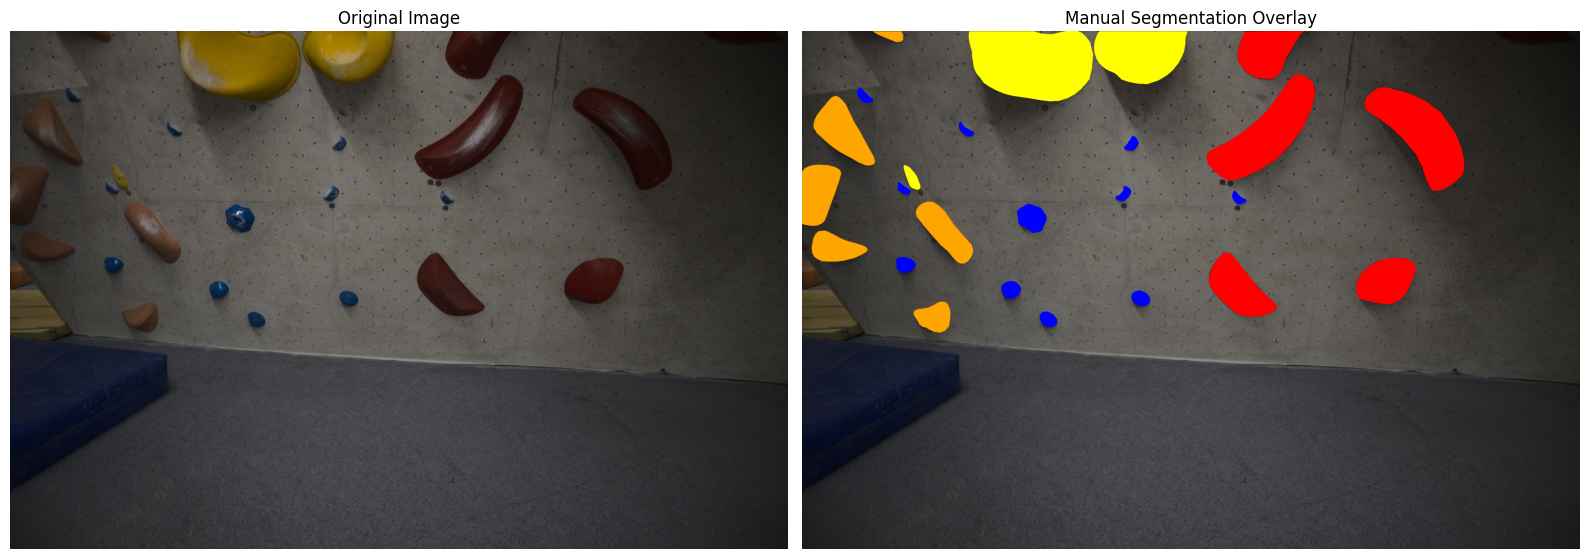

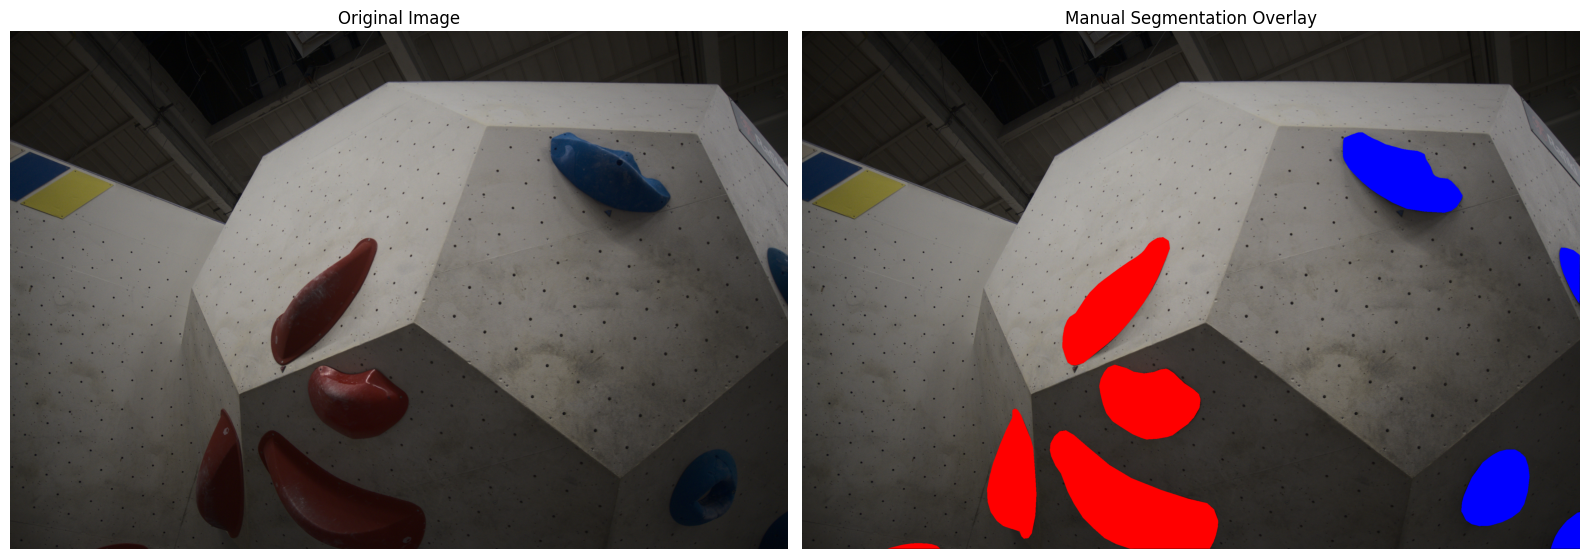

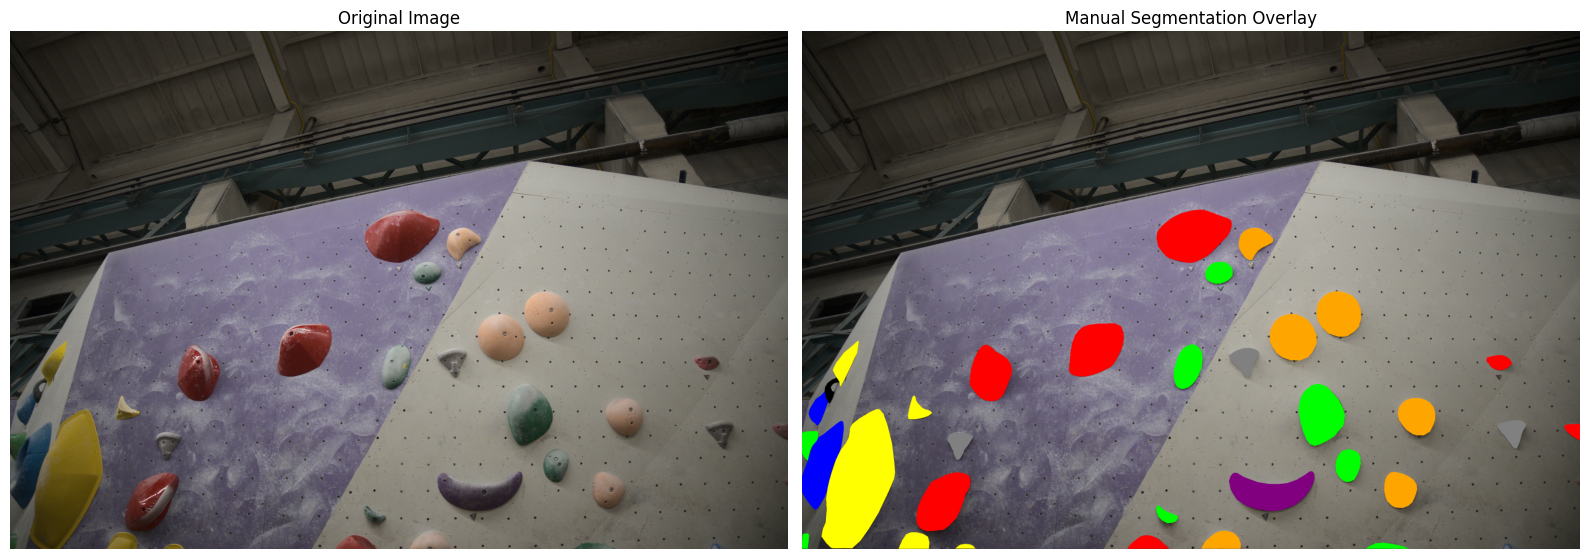

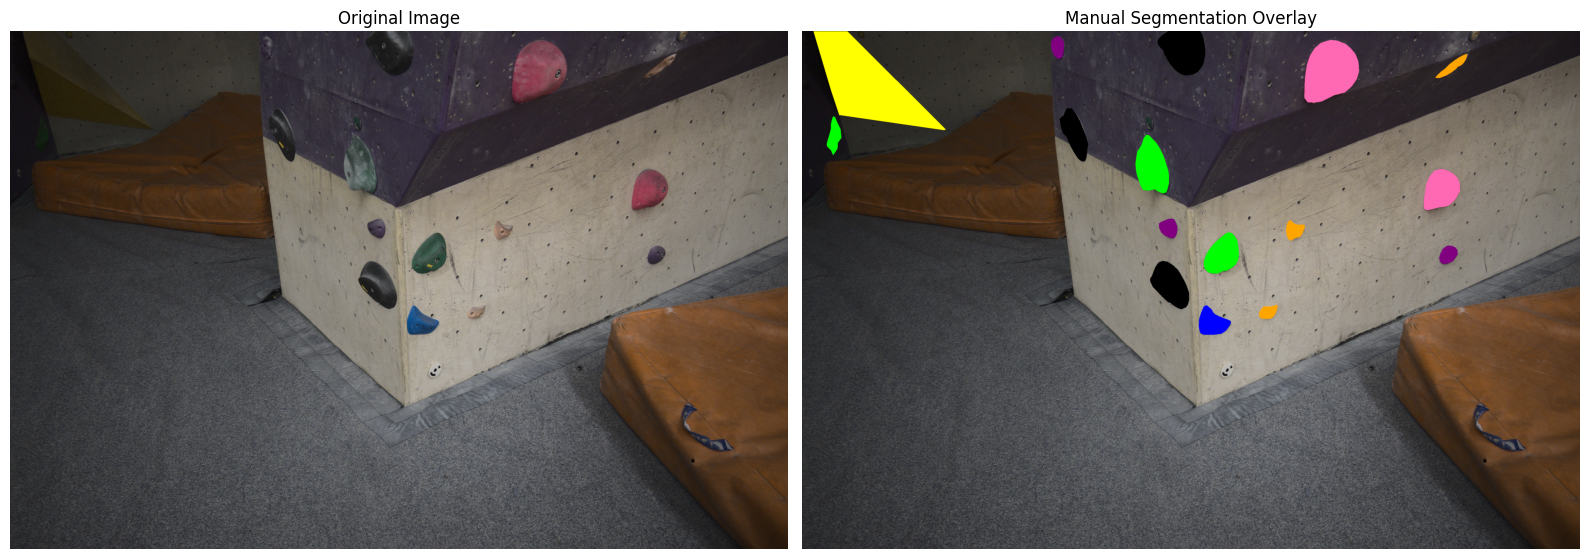

In [4]:
for img_id in ["008", "042", "054", "079", "081", "083", "134", "137", "169", "254"]:
    img, masks = load_sample(img_id)
    visualize(img, masks)